# Homework 1: Probability, Bayes' Rule, and Maximum Likelihood (CPSC 483)
Instructor: Dr. Chia Hsuan Tsai

**Instructions**
- Show your work in the markdown cells (derivations / explanations).
- Complete the code cells where prompted.
- Unless stated otherwise, you may use Python only for arithmetic (the math/derivation should still be written).

This homework is based on the probability + Bayes' rule review (Module 2 Part 1) and MLE review (Module 2 Part 2).

## Problem 1 — Bayes' theorem with TP / TN / FP / FN (confusion matrix)

A disease screening test is used in a population.

You are given:
- **Prevalence**: \(P(D)=0.005\) (0.5% of people truly have the disease)
- **Sensitivity**: \(P(+| D)=0.97\)
- **Specificity**: \(P(-| \neg D)=0.95\)

Recall Bayes' rule (from lecture):
\[
P(D| +)= \frac{P(+| D)P(D)}{P(+| D)P(D)+P(+| \neg D)P(\neg D)}
\]

### Step 1 — Map TP/TN/FP/FN to probabilities
Fill in the definitions (write them as probabilities).

- **TP** (true positive) =  
- **FN** (false negative) =  
- **TN** (true negative) =  
- **FP** (false positive) =  

*Hint:* TP corresponds to “test is + **and** truly diseased”, etc.

### Step 2 — Compute the missing conditional probabilities
Complete:
- \(P(+| \neg D)=\)  
- \(P(-| D)=\)

### Step 3 — Compute posterior probabilities (PPV and NPV)
1. Compute \(P(D| +)\) (this is also called the **positive predictive value**, PPV).
2. Compute \(P(D| -)\).

### Step 4 — Expected counts in a population
If **10,000** people are tested, compute the expected counts of:
- TP, FN, TN, FP

*(Your four numbers should sum to 10,000.)*
### Background: Confusion Matrix (Read Before Answering)

In this question, we use a **binary classifier / medical test** with the following notation:
- `D` : condition (disease) is **present**
- `¬D` : condition (disease) is **absent**
- `+` : test predicts **positive**
- `-` : test predicts **negative**

|                | **Actual D** | **Actual ¬D** |
|----------------|--------------|---------------|
| **Predicted +**| True Positive (TP) | False Positive (FP) |
| **Predicted -**| False Negative (FN) | True Negative (TN) |

**True Positive (TP)**: Test predicts positive and the condition is present.  
Probability: `P(+ | D)`

**False Positive (FP)**: Test predicts positive but the condition is absent.  
Probability: `P(+ | ¬D)`

**False Negative (FN)**: Test predicts negative but the condition is present.  
Probability: `P(- | D)`

**True Negative (TN)**: Test predicts negative and the condition is absent.  
Probability: `P(- | ¬D)`

Use this table to interpret all probabilities in Question 1.

### Step 5 - Evaluation Metric

**Precision**  
Measures how many predicted positives are actually correct.
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
*Interpretation:* Among all **positive predictions**, what fraction are **truly positive**?

**Accuracy**  
Measures overall correctness of the classifier.
$$
\text{Accuracy} = \frac{TP + TN}{TP + FP + FN + TN}
$$
*Interpretation:* What fraction of **all predictions** are **correct**?

Use the confusion matrix above to compute these quantities.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Given values
p_d = 0.0005 # P(D)
p_pos_given_d = 0.97 # P(+|D)
p_neg_given_not_d = 0.95
p_pos_given_not_d = 1 - 0.97
p_neg_given_d = 1- 0.95

# Construct a population size with data
population_size = 100000
actual = np.zeros(population_size)
predicted = np.zeros(population_size)

# Populate actual diseases
num_diseased = int(p_d * population_size)
actual[num_diseased:] = 0 # No disease
actual[:num_diseased] = 1 # Disease

# Populate predictions based on probabilities
# Diseased group
actual_d = actual == 1
actual_not_d = actual == 0

# Corrected line 28
predicted[actual_d] = np.random.choice([1, 0], size=sum(actual_d), p=[p_pos_given_d, 1-p_pos_given_d])
p_pos_given_not_d = 1 - p_neg_given_not_d  # 0.05
p_neg_given_d = 1 - p_pos_given_d          # 0.03

# 2. Compute confusion matrix
cm = confusion_matrix(actual, predicted)

# 3. Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Diagnostic Test')
plt.show()


ValueError: probabilities do not sum to 1

(0.97, 0.030000000000000027, 0.050000000000000044, 0.95, 0.97, 0.96)

## Question 2 — MLE for a Coin: 3 Heads in 5 Throws

You flip a (possibly biased) coin **n = 5** times and observe **k = 3** heads. Let $\theta \in [0,1]$ be the probability of heads.

### Step 1 — Write the likelihood and log-likelihood

1. Write the likelihood $L(\theta \mid k )=P(k \mid \theta)$ for this observation (you may ignore constants that do not depend on $\theta$).
2. Write the log-likelihood $\ell(\theta)=\log L(\theta \mid k )$.

A common simplified form (dropping the binomial coefficient) is:
$$
L(\theta \mid k ) \propto \theta^{k}(1-\theta)^{n-k}.
$$

### Step 2 — Find the MLE $\hat{\theta}_{\text{MLE}}$

Differentiate $\ell(\theta)$ w.r.t. $\theta$, set it to $0$, and solve for $\hat{\theta}_{\text{MLE}}$.

Q2.1 What's your log-likelihood (MLE) form (show the equation of $\ell(\theta)$ after take the differentiation)?, write it down in the cell below:
$$
\ell(\theta)=? ,
$$
where $C$ is a constant that does not depend on $\theta$.
#### Q2.2 After set the $\ell(\theta)$ to zero , Write down your calcuted   $\hat{\theta}_{\text{MLE}}= ? $ (the value of $\hat{\theta}_{\text{MLE}}$) in the cell below


The MLE for the probability of heads is: 0.6






### Step 3 — Quick numeric check in Python

Evaluate the likelihood on a grid of $\theta \in [0,1]$ and verify the maximum occurs near your analytic $\hat{\theta}_{\text{MLE}}$.


MLE for Theta: 0.51


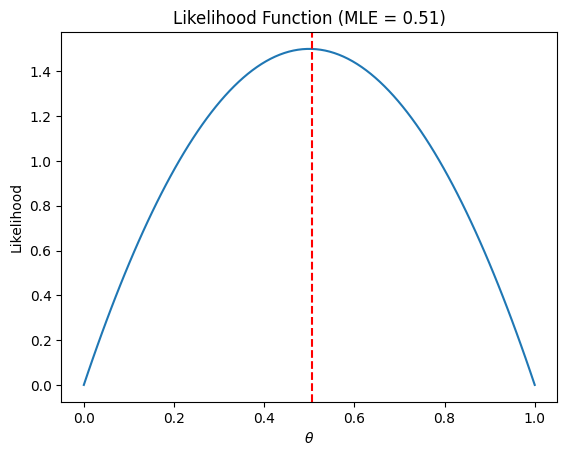

## Question 3 — Maximum Likelihood for a 1D Gaussian (mean MLE)

You are given a dataset $D=\{x_1,\dots,x_N\}$ sampled i.i.d. from a 1D Gaussian:
$$
x_i \sim \mathcal{N}(\mu,\sigma^2),
$$
where $\sigma^2$ is **known** and $\mu$ is unknown.

### Step 1 — Derive the MLE for $\mu$

1. Write the likelihood:
$$
p(D \mid \mu)=\prod_{i=1}^{N}\mathcal{N}(x_i \mid \mu,\sigma^2).
$$


2. Write the log-likelihood $\ell(\mu \mid D )=\log p(D\mid \mu)$.
Please check page 41 of module 2.2 PDF file for the likelihood equation (for log likelihood, take a log,then differentiate with respect to 𝜇 to get  $\hat{\mu} $)

3. Differentiate w.r.t. $\mu$, set it to $0$, and solve for $\hat{\mu}$.

You should obtain the **sample mean**:
$$
\hat{\mu}=\frac{1}{N}\sum_{i=1}^{N}x_i.
$$

### Step 2 — Compute the MLE for a concrete dataset

Use the dataset below and compute $\hat{\mu}$ in Python.


mu_hat: 1.0, sigma_sq_hat: 0.019999999999999997


np.float64(2.05)

<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Troy\AppData\Local\Temp\ipykernel_3180\3101596178.py:26: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(mu_vals, log_likelihoods, label='Log-Likelihood $\ell(\mu)$', color='blue', lw=2)
C:\Users\Troy\AppData\Local\Temp\ipykernel_3180\3101596178.py:27: SyntaxWarning: invalid escape sequence '\h'
  plt.axvline(mu_hat, color='red', linestyle='--', label=f'MLE $\hat{{\mu}} = {mu_hat:.2f}$')
C:\Users\Troy\AppData\Local\Temp\ipykernel_3180\3101596178.py:27: SyntaxWarning: in

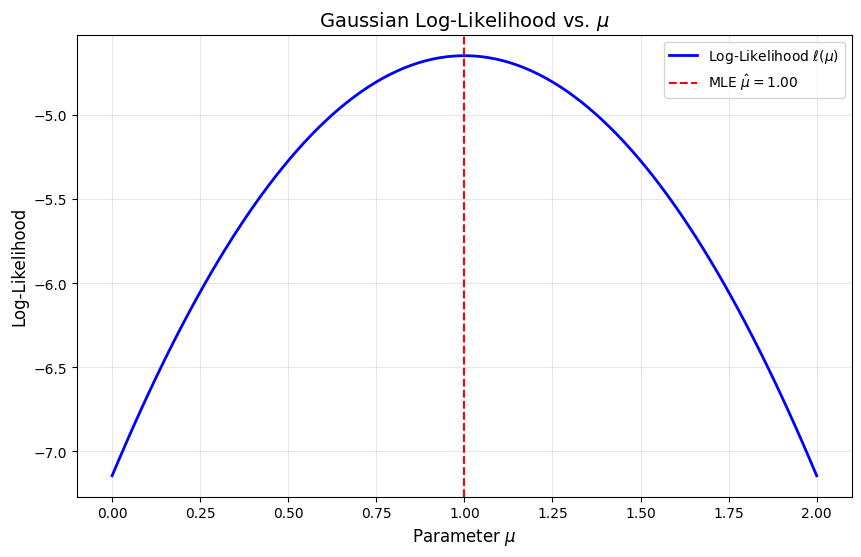